# Basic temperature model
A basic model that predicts the room temperature for a house over the next 30 hours

Variables in:
- Room temperature
- User setpoint temperature
- External temperature

Variables out:
- Room temperature

In [ ]:
import os
from datetime import datetime
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DayLocator, DateFormatter, HourLocator
import numpy as np

## Preprocessing
### Load data

In [ ]:
data_path = "data/PST_Data_20260220"
temperature_files = [f for f in glob(os.path.join(data_path, "*.csv")) if "Events" not in f]

In [ ]:
houses_to_exclude = ['30097']

In [4]:
house_data = {}
for house_index in range(len(temperature_files)):
    house_id = temperature_files[house_index].split("/")[-1].split("_")[0]
    if house_id not in houses_to_exclude:
        # Don't include the above houses
        print('Loading data for house ID: ', house_id)
        house_df = pd.read_csv(temperature_files[house_index])
        print('Data quantity in house: ', len(house_df))
        # Store only variables needed for training
        df = pd.DataFrame({})
        # Convert time to datetime
        df['Datetime'] = [datetime.strptime(t, '%Y-%m-%d %H:%M') for t in house_df['Time (UTC)'].values]
        df['Room temperature'] = house_df['Room temperature (Zone 1) (°C)']
        df['User setpoint'] = house_df['Setpoint temperature (Zone 1) (°C)']
        df['External temperature'] = house_df['External temperature (°C)']

        house_data[house_id] = df

# Model for a house

In [5]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import numpy as np

In [6]:
house_id = '30436'
model_save_path = f"models/{house_id}_room_setpoint_50_win_1000_ep.pt"

# Extract data
house_df = house_data[house_id]

# Data cleaning - for now will just drop parts of dataframe which have NaN
house_df = house_df.dropna()
input_features = house_df[['Room temperature', 'User setpoint']].values  # 'External temperature'
target = house_df['Room temperature'].values

In [7]:
print(len(input_features))
print(len(target))

39288
39288


In [8]:
scaler = MinMaxScaler()
input_features = scaler.fit_transform(input_features)

In [9]:
# Split the data into training and testing sets
train_size = int(len(input_features) * 0.8)
train_input = input_features[:train_size]
test_input = input_features[train_size:]
train_target = target[:train_size]
test_target = target[train_size:]
test_dates = house_df["Datetime"].values[train_size:]

In [10]:
def create_sequences(input_data, target_data, seq_length):
    """Creates sequences of seq_length steps in input data,
    predicting next step in target data"""
    inp_seq = []
    tgt_seq = []
    for i in range(len(input_data) - seq_length):
        inp_seq.append(input_data[i:i + seq_length])
        tgt_seq.append(target_data[i + seq_length])
    inp_seq = np.array(inp_seq)
    tgt_seq = np.array(tgt_seq)
    return torch.tensor(inp_seq, dtype=torch.float32), torch.tensor(tgt_seq, dtype=torch.float32)


seq_length = 50 # int((30*60)/15)
train_inp_seq, train_tgt_seq = create_sequences(train_input, train_target, seq_length)
test_inp_seq, test_tgt_seq = create_sequences(test_input, test_target, seq_length)

In [11]:
class MultivariateLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(MultivariateLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

input_size = train_inp_seq.shape[2]
hidden_size = 32
num_layers = 2
output_size = 1

model = MultivariateLSTM(input_size, hidden_size, num_layers, output_size)

In [12]:
print(input_size)

2


In [13]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 1000
losses = []
for epoch in range(num_epochs):
    outputs = model(train_inp_seq)
    optimizer.zero_grad()
    loss = criterion(outputs, train_tgt_seq.unsqueeze(1))
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')
    losses.append(loss.item())

Epoch [10/1000], Loss: 488.2955
Epoch [20/1000], Loss: 477.6187
Epoch [30/1000], Loss: 447.4289
Epoch [40/1000], Loss: 404.3376
Epoch [50/1000], Loss: 371.9144
Epoch [60/1000], Loss: 344.9851
Epoch [70/1000], Loss: 321.9493
Epoch [80/1000], Loss: 302.2972
Epoch [90/1000], Loss: 285.6996
Epoch [100/1000], Loss: 271.1052
Epoch [110/1000], Loss: 257.8514
Epoch [120/1000], Loss: 245.5860
Epoch [130/1000], Loss: 234.1106
Epoch [140/1000], Loss: 223.2987
Epoch [150/1000], Loss: 213.0627
Epoch [160/1000], Loss: 203.3384
Epoch [170/1000], Loss: 194.0767
Epoch [180/1000], Loss: 185.2387
Epoch [190/1000], Loss: 176.7930
Epoch [200/1000], Loss: 168.7135
Epoch [210/1000], Loss: 160.9778
Epoch [220/1000], Loss: 153.5667
Epoch [230/1000], Loss: 146.4635
Epoch [240/1000], Loss: 139.6532
Epoch [250/1000], Loss: 133.1223
Epoch [260/1000], Loss: 126.8586
Epoch [270/1000], Loss: 120.8509
Epoch [280/1000], Loss: 115.0889
Epoch [290/1000], Loss: 109.5630
Epoch [300/1000], Loss: 104.2642
Epoch [310/1000], L

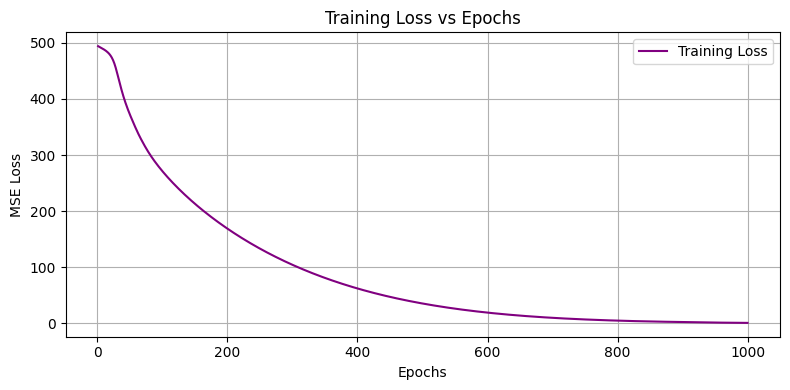

In [14]:
# Plot the loss at each epoch to visualize model convergence
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), losses, label='Training Loss', color='purple')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training Loss vs Epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

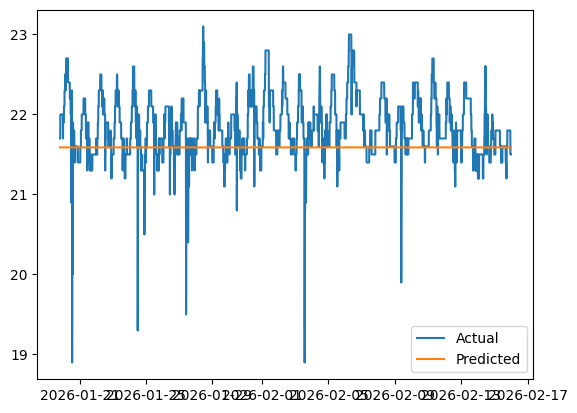

In [15]:
model.eval()
with torch.no_grad():
    test_predictions = model(test_inp_seq).numpy().flatten()

# Plot the results
plt.plot(test_dates[seq_length:], test_target[seq_length:], label='Actual')
plt.plot(test_dates[seq_length:], test_predictions, label='Predicted')
plt.legend()
plt.show()

In [16]:
torch.save(model.state_dict(), model_save_path)

In [17]:
model = MultivariateLSTM(input_size, hidden_size, num_layers, output_size)
model.load_state_dict(torch.load(model_save_path, weights_only=True))
model.eval()

MultivariateLSTM(
  (lstm): LSTM(2, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

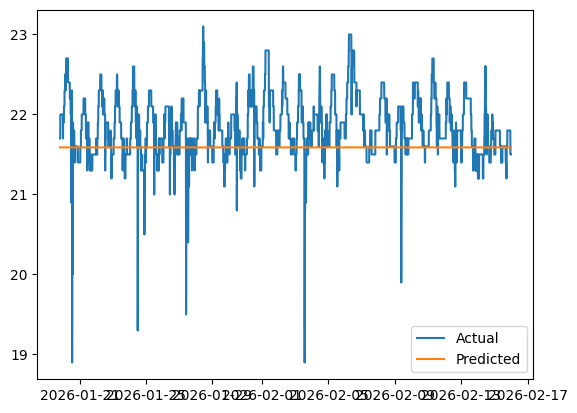

In [18]:
with torch.no_grad():
    test_predictions = model(test_inp_seq).numpy().flatten()

# Plot the results
plt.plot(test_dates[seq_length:], test_target[seq_length:], label='Actual')
plt.plot(test_dates[seq_length:], test_predictions, label='Predicted')
plt.legend()
plt.show()

### Forecast

In [19]:
# PROBLEM: predicted value is only the temperature,
# need to somehow append the true test user setpoint and ext temp to continuously forecast
# and the predicted room temp?
#
# OR does it need to predict all of these values!?
# No can't be the second one as this isn't the goal... maybe it can only do one step "blind"
# By design - only predicting temp so can't infinitely forecast unless have the next set of steps?

# AH! Our model would have ext temp forecast and user setpoint encoded in... so its okay!
# Not forecasting, just predicting next 30 hours.

### Evaluate

In [20]:
# RMSE? MAE?